# TWO-DIMENSIONAL TOY EXAMPLES

In [1]:
import warnings
warnings.filterwarnings('ignore')

import math, time
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from dataclasses import dataclass
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from functools import partial
from tqdm import tqdm as _tqdm
from sklearn.datasets import make_swiss_roll
from sklearn.neighbors import NearestNeighbors

tqdm = partial(_tqdm, disable=True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

DEVICE = 'cuda'
SEEDS = [0, 1, 2]
NFES = [1, 2, 4, 8, 16, 32]
N_TRAIN, EVAL_N, BS, D = 20000, 5000, 512, 2
EPOCHS = 600
K_EXP = 8 

print(torch.__version__)

2.7.1+cu126


## Data

In [2]:
def _cont2disc(x, V, qrange=(-3, 3)):
    edges = torch.linspace(qrange[0], qrange[1], V - 1)
    if isinstance(x, np.ndarray):
        x = torch.tensor(x)
    return torch.bucketize(x, edges)


def gen_8modes(n, seed, V=50, D=2, M=8, sigma=0.09):
    """M gaussian modes in R^D."""
    rng = np.random.RandomState(seed)
    centers = rng.uniform(-2.5, 2.5, size=(M, D))
    idx = rng.randint(0, M, size=n)
    pts = centers[idx] + sigma * rng.randn(n, D)
    gen_8modes.centers = centers
    return _cont2disc(pts, V).long(), idx


def gen_swiss_roll(n, seed, V=50, D=2, M=None):
    """Swiss-roll 2D manifold lifted into D ambient dims."""
    base = make_swiss_roll(n_samples=n, noise=0.45, random_state=seed)[0][:, [0, 2]] / 7.5
    if D == 2:
        raw = base
    else:
        rng = np.random.RandomState(seed + 777)
        W = rng.randn(2, D); W /= np.linalg.norm(W, axis=0, keepdims=True)
        raw = base @ W
    return _cont2disc(raw, V).long(), None


DATASETS = {
    'swiss_roll': dict(gen=gen_swiss_roll, V=50, M=None, spatial=True),
    '8modes': dict(gen=gen_8modes, V=50, M=8, spatial=True),
}


def support_validity(samples, train, sub=3000):
    tr = train[:sub].astype(np.float64)
    nn = NearestNeighbors(n_neighbors=2).fit(tr)
    dtr, _ = nn.kneighbors(tr)
    thr = float(np.percentile(dtr[:, 1], 90))
    ds, _ = nn.kneighbors(samples[:sub].astype(np.float64))
    return float((ds[:, 0] <= thr).mean())

## GT data visualization (8-Modes, Swiss-roll)

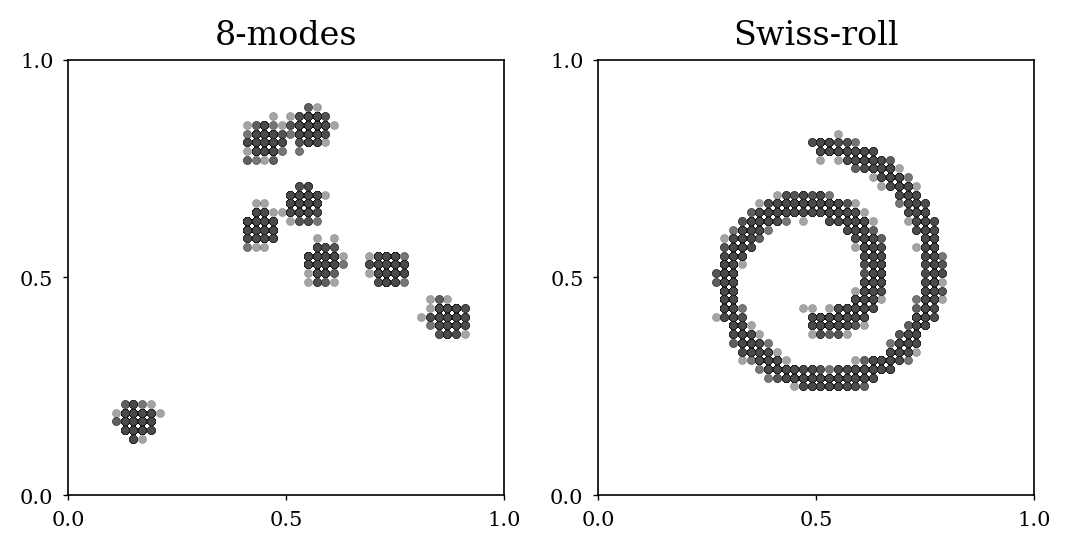

In [14]:
GT_COLOR = '#4a4a4a'
C_MDLM = '#D98C86'
C_VADD = '#8FB5DC'
C_EMOE = '#1F4E8C'

%config InlineBackend.figure_format = 'retina'

def _undiscretise(tok, V):
    if isinstance(tok, torch.Tensor):
        tok = tok.cpu().numpy()
    return (tok.astype(np.float64) + 0.5) / V


DATASET_LABELS = {'8modes': '8-modes', 'swiss_roll': 'Swiss-roll'}
N_SHOW, cell = 6000, 5.2


S = 0.5 
cell = 5.2 * S
fig, axes = plt.subplots(1, 2, figsize=(cell * 2 + 0.5 * S, cell + 0.8 * S))
for ax, ds_name in zip(axes, ['8modes', 'swiss_roll']):
    ds = DATASETS[ds_name]
    tokens, _ = ds['gen'](20000, 0, V=ds['V'], D=2, M=ds['M'])
    xy = _undiscretise(tokens[:N_SHOW], ds['V'])
    ax.scatter(xy[:, 0], xy[:, 1], s=34 * S**2, alpha=0.5, c=GT_COLOR,
                edgecolors='black', linewidths=0.25 * S, rasterized=True)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.tick_params(labelsize=15 * S, width=S, length=3.5 * S)
    ax.set_aspect('equal')
    ax.set_title(DATASET_LABELS[ds_name], fontsize=24 * S, pad=11 * S)
    for sp in ax.spines.values():
        sp.set_edgecolor('black'); sp.set_linewidth(1.2 * S)
plt.tight_layout()
plt.show()

## Model

All methods use the same backbone, simple Transformer implementation

In [4]:
@dataclass
class C:
    V: int # vocab size (without MASK token)
    L: int # seq length
    H: int = 128
    SIN: int = 64
    K: int = 8 # num experts in E-MoE
    topk: int = 2
    routing_mode: str = 'per_token' # routing mode: 'per_token' or 'sequence_level'
    n_layers: int = 2
    n_heads: int = 4
    mlp_ratio: int = 4
    bs: int = 512 # batch size
    lr: float = 3e-4 # learning rate
    epochs: int = 300
    diffusion_steps: int = 64
    kl_weight: float = 1.0
    lb_weight: float = 0.1 # load-balancing loss weight in E-MoE
    gumbel_tau_init: float = 1.0
    gumbel_tau_min: float = 0.1
    gumbel_tau_anneal_rate: float = 3e-5

    @property
    def MASK(self):
        return self.V

def alpha(t):
    return 1.0 - t

def sample_xt(x0, t, MASK):
    keep = torch.rand_like(x0.float()) < alpha(t)[:, None]
    return torch.where(keep, x0, torch.full_like(x0, MASK))

def sin_embed(t, dim=64):
    half = dim // 2
    f = torch.exp(torch.linspace(0, math.log(1000), half, device=t.device))
    a = t[:, None] * f[None]
    return torch.cat([a.sin(), a.cos()], dim=-1)


class TransformerBlock(nn.Module):
    def __init__(self, H, n_heads, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(H)
        self.norm2 = nn.LayerNorm(H)
        self.attn = nn.MultiheadAttention(H, n_heads, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(H, mlp_ratio * H), nn.GELU(),
                                 nn.Linear(mlp_ratio * H, H))

    def forward(self, x):
        # x here is (B, L, H), where B - batch size, L - seq.len (=2 [x, y]), H - hidden dim
        n1 = self.norm1(x)
        a, _ = self.attn(n1, n1, n1, need_weights=False)
        x = x + a # residual connection
        return x + self.mlp(self.norm2(x)) # mlp then again residual connection

 ### E-MoE block
 
The MLP is replaced by $K$ experts with a router. Routing is a top-2 Gumbel-softmax with a STE hard decision of one expert per token

In [5]:
def topk_gumbel_ste(routing_logits, K, topk, tau):
    w = F.gumbel_softmax(routing_logits.float(), tau=tau, hard=False, dim=-1)
    sel_w, sel_e = w.topk(topk, dim=-1)
    sel_w = sel_w / (sel_w.sum(dim=-1, keepdim=True) + 1e-8)
    hard_idx = sel_w.argmax(dim=-1, keepdim=True)
    hard_w_topk = torch.zeros_like(sel_w).scatter_(-1, hard_idx, 1.0)
    hard_w = (hard_w_topk - sel_w).detach() + sel_w
    full_w = torch.zeros_like(routing_logits.float())
    full_w.scatter_(-1, sel_e, hard_w)
    return full_w


class MoEBlock(nn.Module):
    def __init__(self, H, n_heads, mlp_ratio=4, K=8, topk=2, routing_mode='per_token'):
        super().__init__()
        self.K = K
        self.topk = topk
        self.routing_mode = routing_mode
        self.norm1 = nn.LayerNorm(H)
        self.norm2 = nn.LayerNorm(H)
        self.attn = nn.MultiheadAttention(H, n_heads, batch_first=True)
        self.experts = nn.ModuleList([
            nn.Sequential(nn.Linear(H, mlp_ratio * H), nn.GELU(),
                          nn.Linear(mlp_ratio * H, H)) for _ in range(K)])
        self.router = nn.Linear(H, K, bias=False)
        nn.init.normal_(self.router.weight, std=0.02)

    def forward(self, x, force_route_logits=None, tau=1.0):
        n1 = self.norm1(x)
        a, _ = self.attn(n1, n1, n1, need_weights=False)
        x = x + a
        h_pre = self.norm2(x)                                # (B, L, H)
        if self.routing_mode == 'sequence_level':
            pooled = h_pre.mean(dim=1).float()               # (B, H)
            self_router_logits = self.router(pooled)         # (B, K)
        else:
            self_router_logits = self.router(h_pre.float())  # (B, L, K)
        routing_logits = (force_route_logits if force_route_logits is not None
                          else self_router_logits)
        w = topk_gumbel_ste(routing_logits, self.K, self.topk, tau)
        if self.routing_mode == 'sequence_level':
            full_w = w.unsqueeze(1).expand(-1, h_pre.shape[1], -1)
        else:
            full_w = w
        all_outs = torch.stack([e(h_pre) for e in self.experts], dim=0)
        moe_out = torch.einsum("kblh,blk->blh", all_outs, full_w.to(all_outs.dtype))
        return x + moe_out, self_router_logits


class Backbone(nn.Module):
    def __init__(self, c: C, use_moe=False):
        super().__init__()
        self.c = c; self.use_moe = use_moe
        self.tok_emb = nn.Embedding(c.V + 1, c.H)            # +1 for MASK
        self.pos_emb = nn.Embedding(c.L, c.H)
        self.time_mlp = nn.Sequential(nn.Linear(c.SIN, c.H), nn.SiLU(), nn.Linear(c.H, c.H))
        if use_moe:
            self.blocks = nn.ModuleList([
                MoEBlock(c.H, c.n_heads, c.mlp_ratio, K=c.K, topk=c.topk,
                         routing_mode=c.routing_mode)
                for _ in range(c.n_layers)])
        else:
            self.blocks = nn.ModuleList([
                TransformerBlock(c.H, c.n_heads, c.mlp_ratio)
                for _ in range(c.n_layers)])
        self.head_norm = nn.LayerNorm(c.H)
        self.head = nn.Linear(c.H, c.V)

    def embed(self, xt, t):
        pos = self.pos_emb(torch.arange(self.c.L, device=xt.device))
        te = self.time_mlp(sin_embed(t, dim=self.c.SIN))[:, None, :]
        return self.tok_emb(xt) + pos[None] + te

    def forward_mdlm(self, xt, t):
        x = self.embed(xt, t)
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.head_norm(x))

    def forward_moe(self, xt, t, force_routes=None, tau=1.0):
        x = self.embed(xt, t)
        all_rl = []
        for i, blk in enumerate(self.blocks):
            force_d = force_routes[i] if force_routes is not None else None
            x, rl = blk(x, force_route_logits=force_d, tau=tau)
            all_rl.append(rl)
        return self.head(self.head_norm(x)), all_rl

## Training, losses and sampling loops for each one model

### MDLM

In [ ]:
def kl_per_layer(qlist, plist):
    total = 0
    for ql, pl in zip(qlist, plist):
        log_q = F.log_softmax(ql, dim=-1)
        log_p = F.log_softmax(pl, dim=-1)
        q = log_q.exp()
        total = total + (q * (log_q - log_p)).sum(dim=-1)
    return total


def train_mdlm(c: C, tokens, log):
    model = Backbone(c, use_moe=False).to(DEVICE)
    loader = DataLoader(TensorDataset(tokens), batch_size=c.bs, shuffle=True, drop_last=True)
    opt = torch.optim.Adam(model.parameters(), lr=c.lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=c.epochs * len(loader))
    pbar = tqdm(range(c.epochs), desc='MDLM', leave=False)
    for _ in pbar:
        for (x0_cpu,) in loader:
            x0 = x0_cpu.to(DEVICE); B = x0.shape[0]
            t = torch.rand(B, device=DEVICE).clamp(min=1.0 / c.diffusion_steps, max=1.0)
            xt = sample_xt(x0, t, c.MASK)
            mask = (xt == c.MASK).float()

            # Final MDLM objective, ELBO loss
            ce = F.cross_entropy(model.forward_mdlm(xt, t).reshape(-1, c.V),
                                 x0.reshape(-1), reduction='none').view(B, c.L)
            recon = ((ce * mask).sum(dim=1) / t.clamp_min(1e-3)).mean()

            opt.zero_grad()
            recon.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()
            log['recon'].append(recon.item())
        pbar.set_postfix(recon=f'{recon.item():.3f}')
    return model


@torch.no_grad()
def sample_mdlm(model, n, nfe, c: C):
    model.eval()
    x = torch.full((n, c.L), c.MASK, dtype=torch.long, device=DEVICE)
    ts = torch.linspace(1, 0, nfe + 1, device=DEVICE)
    for i in range(nfe):
        tc = torch.full((n,), ts[i].item(), device=DEVICE)
        tp = torch.full((n,), ts[i + 1].item(), device=DEVICE)
        probs = F.softmax(model.forward_mdlm(x, tc), dim=-1)
        a_c, a_p = alpha(tc)[:, None], alpha(tp)[:, None]
        p_un = ((a_p - a_c) / (1.0 - a_c + 1e-8)).clamp(0, 1)
        choose = (torch.rand_like(x.float()) < p_un) & (x == c.MASK)
        if choose.any():
            x = torch.where(choose,
                torch.multinomial(probs.reshape(-1, c.V), 1).view_as(x), x)
    rem = x == c.MASK
    if rem.any():
        t0 = torch.zeros(n, device=DEVICE)
        probs = F.softmax(model.forward_mdlm(x, t0), dim=-1)
        fill = torch.multinomial(probs.reshape(-1, c.V), 1).view_as(x)
        x = torch.where(rem, fill, x)
    model.train()
    return x.cpu().numpy()


### E-MoE

Two forward-passes per step: pass A runs the clean $x_0$ and gives the clean router logits (posterior), pass B runs the
noisy masked $x_t$ (prior).

In [8]:
def lb_aux(route_logits_list, K):
    """Load balance correction"""
    tot = 0.0
    for rl in route_logits_list:
        p = F.softmax(rl.float(), dim=-1)
        P = p.mean(dim=(0, 1))
        f = F.one_hot(p.argmax(-1), K).float().mean(dim=(0, 1))
        tot = tot + K * (f * P).sum()
    return tot / len(route_logits_list)


def train_emoe(c: C, tokens, log):
    model = Backbone(c, use_moe=True).to(DEVICE)
    loader = DataLoader(TensorDataset(tokens), batch_size=c.bs, shuffle=True, drop_last=True)
    opt = torch.optim.Adam(model.parameters(), lr=c.lr)
    total_steps = c.epochs * len(loader)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_steps)
    tau_decay = math.log(c.gumbel_tau_init / c.gumbel_tau_min)
    step = 0
    pbar = tqdm(range(c.epochs), desc='E-MoE', leave=False)
    for _ in pbar:
        for (x0_cpu,) in loader:
            step += 1
            x0 = x0_cpu.to(DEVICE)
            B = x0.shape[0]
            t = torch.rand(B, device=DEVICE).clamp(min=1.0 / c.diffusion_steps, max=1.0)
            xt = sample_xt(x0, t, c.MASK)
            mask = (xt == c.MASK).float()
            tau = max(c.gumbel_tau_min, c.gumbel_tau_init * math.exp(-tau_decay * step / total_steps))

            # Pass A (Posterior): clean x0 -> clean router logits
            t0 = torch.zeros(B, device=DEVICE) + 1.0 / c.diffusion_steps
            _, clean_rl = model.forward_moe(x0, t0, force_routes=None, tau=tau)

            # Pass B (Prior): noisy xt with force_routes = clean_router_logits
            logits, noisy_rl = model.forward_moe(xt, t, force_routes=clean_rl, tau=tau)

            # Reconstruction term
            ce = F.cross_entropy(logits.reshape(-1, c.V), x0.reshape(-1), reduction='none').view(B, c.L) # calculate here −log p_θ(x0_i | x_t)
            recon = ((ce * mask).sum(dim=1) / t.clamp_min(1e-3)).mean() # loss only on masked tokens (mask = (xt == MASK))

            # KL-divergence term
            kl_per = kl_per_layer(clean_rl, noisy_rl)
            kl_per_sample = kl_per.mean(dim=1) if kl_per.dim() > 1 else kl_per
            kl_term = (kl_per_sample / t.clamp_min(1e-3)).mean() # KL(clean router ‖ noisy router), division by t is optional 
            
            # Full ELBO loss with LB correction
            total = (recon + c.kl_weight * kl_term + c.lb_weight * lb_aux(noisy_rl, c.K))

            opt.zero_grad()
            total.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()

            log['recon'].append(recon.item())
            log['kl'].append(float(kl_term.detach()))
            log['tau'].append(tau)
        pbar.set_postfix(recon=f'{recon.item():.3f}', kl=f'{float(kl_term):.3f}', tau=f'{tau:.3f}')
    return model


# base ancestral sampling
@torch.no_grad()
def sample_emoe(model, n, nfe, c: C, tau=0.1):
    model.eval()
    x = torch.full((n, c.L), c.MASK, dtype=torch.long, device=DEVICE)
    ts = torch.linspace(1, 0, nfe + 1, device=DEVICE)
    for i in range(nfe):
        tc = torch.full((n,), ts[i].item(), device=DEVICE) # t current
        tp = torch.full((n,), ts[i + 1].item(), device=DEVICE) # t previous
        logits, _ = model.forward_moe(x, tc, force_routes=None, tau=tau)
        probs = F.softmax(logits, dim=-1)
        a_c, a_p = alpha(tc)[:, None], alpha(tp)[:, None]
        p_un = ((a_p - a_c) / (1.0 - a_c + 1e-8)).clamp(0, 1)
        choose = (torch.rand_like(x.float()) < p_un) & (x == c.MASK)
        if choose.any():
            x = torch.where(choose,
                torch.multinomial(probs.reshape(-1, c.V), 1).view_as(x), x)
    rem = x == c.MASK
    if rem.any():
        t0 = torch.zeros(n, device=DEVICE)
        logits, _ = model.forward_moe(x, t0, force_routes=None, tau=tau)
        probs = F.softmax(logits, dim=-1)
        fill = torch.multinomial(probs.reshape(-1, c.V), 1).view_as(x)
        x = torch.where(rem, fill, x)
    model.train()
    return x.cpu().numpy()


### VADD

In [ ]:
class VADDEncoder(nn.Module):
    """Posterior rphi(z|x0, xt): predicts (mu, logstd) of latent z from clean x0
    and the mask indicator Mt = (xt == MASK). Conditioning on xt guards collapse."""
    def __init__(self, c: C, latent_dim: int = 8):
        super().__init__()
        self.c = c
        self.latent_dim = latent_dim
        self.tok_emb = nn.Embedding(c.V + 1, c.H)
        self.pos_emb = nn.Embedding(c.L, c.H)
        self.mask_emb = nn.Embedding(2, c.H) 
        self.time_mlp = nn.Sequential(nn.Linear(c.SIN, c.H), nn.SiLU(), nn.Linear(c.H, c.H))
        self.blocks = nn.ModuleList([
            TransformerBlock(c.H, c.n_heads, c.mlp_ratio)
            for _ in range(c.n_layers)])
        self.head_norm = nn.LayerNorm(c.H)
        self.head = nn.Linear(c.H, 2 * latent_dim)

    def forward(self, x0, t, mask_t):
        pos = self.pos_emb(torch.arange(self.c.L, device=x0.device))
        te = self.time_mlp(sin_embed(t, dim=self.c.SIN))[:, None, :]
        me = self.mask_emb(mask_t.long()) # (B, L, H)
        x = self.tok_emb(x0) + pos[None] + te + me
        for blk in self.blocks:
            x = blk(x)
        out = self.head(self.head_norm(x)).mean(dim=1)
        mu, logstd = torch.chunk(out, 2, dim=-1)
        logstd = logstd.clamp(min=-4, max=2)
        return mu, logstd


class VADDDecoder(nn.Module):
    def __init__(self, c: C, latent_dim: int = 8):
        super().__init__()
        self.c = c
        self.tok_emb = nn.Embedding(c.V + 1, c.H)
        self.pos_emb = nn.Embedding(c.L, c.H)
        self.time_mlp = nn.Sequential(nn.Linear(c.SIN, c.H), nn.SiLU(), nn.Linear(c.H, c.H))
        self.z_proj = nn.Sequential(nn.Linear(latent_dim, c.H), nn.SiLU(), nn.Linear(c.H, c.H))
        self.blocks = nn.ModuleList([
            TransformerBlock(c.H, c.n_heads, c.mlp_ratio)
            for _ in range(c.n_layers)])
        self.head_norm = nn.LayerNorm(c.H)
        self.head = nn.Linear(c.H, c.V)

    def forward(self, xt, t, z):
        pos = self.pos_emb(torch.arange(self.c.L, device=xt.device))
        te = self.time_mlp(sin_embed(t, dim=self.c.SIN))[:, None, :]
        ze = self.z_proj(z)[:, None, :]
        x = self.tok_emb(xt) + pos[None] + te + ze
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.head_norm(x))


def train_vadd(c: C, tokens, log, latent_dim: int = 8, init_kl_weight: float = 0.001, kl_warmup_frac: float = 0.3):
    enc = VADDEncoder(c, latent_dim).to(DEVICE)
    dec = VADDDecoder(c, latent_dim).to(DEVICE)
    params = list(enc.parameters()) + list(dec.parameters())
    loader = DataLoader(TensorDataset(tokens), batch_size=c.bs, shuffle=True, drop_last=True)
    opt = torch.optim.Adam(params, lr=c.lr)
    total_steps = c.epochs * len(loader)
    warmup_steps = int(kl_warmup_frac * total_steps)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_steps)
    
    step = 0
    pbar = tqdm(range(c.epochs), desc='VADD', leave=False)
    for _ in pbar:
        for (x0_cpu,) in loader:
            step += 1
            kl_weight = init_kl_weight + (1.0 - init_kl_weight) * min(
                1.0, step / max(1, warmup_steps))
            x0 = x0_cpu.to(DEVICE)
            B = x0.shape[0]
            t = torch.rand(B, device=DEVICE).clamp(min=1.0 / c.diffusion_steps, max=1.0)
            xt = sample_xt(x0, t, c.MASK)
            mask = (xt == c.MASK).float()
            mask_t = (xt == c.MASK)
            mu, logstd = enc(x0, t, mask_t)
            std = logstd.exp()
            z = mu + std * torch.randn_like(mu)

            kl = 0.5 * (mu.pow(2) + std.pow(2) - 1.0 - 2 * logstd).sum(dim=-1)
            kl_term = (kl / t.clamp_min(1e-3)).mean()

            logits = dec(xt, t, z)
            ce = F.cross_entropy(logits.reshape(-1, c.V), x0.reshape(-1), reduction='none').view(B, c.L)
            recon = ((ce * mask).sum(dim=1) / t.clamp_min(1e-3)).mean()
            loss = recon + kl_weight * kl_term

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()
            sched.step()
            log['recon'].append(recon.item())
            log['kl'].append(float(kl_term.detach()))
            log.setdefault('kl_weight', []).append(kl_weight)
        pbar.set_postfix(recon=f'{recon.item():.3f}',
                         kl=f'{float(kl_term):.3f}', klw=f'{kl_weight:.3f}')
    return enc, dec


@torch.no_grad()
def sample_vadd(models, n, nfe, c: C):
    enc, dec = models
    dec.eval()
    x = torch.full((n, c.L), c.MASK, dtype=torch.long, device=DEVICE)
    ts = torch.linspace(1, 0, nfe + 1, device=DEVICE)
    for i in range(nfe):
        tc = torch.full((n,), ts[i].item(), device=DEVICE)
        tp = torch.full((n,), ts[i + 1].item(), device=DEVICE)
        z = torch.randn(n, enc.latent_dim, device=DEVICE)
        logits = dec(x, tc, z)
        probs = F.softmax(logits, dim=-1)
        a_c, a_p = alpha(tc)[:, None], alpha(tp)[:, None]
        p_un = ((a_p - a_c) / (1.0 - a_c + 1e-8)).clamp(0, 1)
        choose = (torch.rand_like(x.float()) < p_un) & (x == c.MASK)
        if choose.any():
            x = torch.where(choose,
                torch.multinomial(probs.reshape(-1, c.V), 1).view_as(x), x)
    rem = x == c.MASK
    if rem.any():
        t0 = torch.zeros(n, device=DEVICE)
        z = torch.randn(n, enc.latent_dim, device=DEVICE)
        logits = dec(x, t0, z)
        probs = F.softmax(logits, dim=-1)
        fill = torch.multinomial(probs.reshape(-1, c.V), 1).view_as(x)
        x = torch.where(rem, fill, x)
    dec.train()
    return x.cpu().numpy()


In [15]:
def _batched_sample(model, sample_fn, N, nfe, c, **kw):
    out = []
    rem = N
    B = 2000
    while rem > 0:
        b = min(B, rem)
        out.append(sample_fn(model, b, nfe, c, **kw))
        rem -= b
    return np.concatenate(out, axis=0)

## Training and evaluation

In [ ]:
def train_model(ds_name, seed):
    torch.set_num_threads(2)
    t0 = time.time()
    ds = DATASETS[ds_name]
    V = ds['V']
    c = C(V=V, L=D, epochs=EPOCHS, bs=BS, K=K_EXP, topk=2)
    torch.manual_seed(seed)
    np.random.seed(seed)
    tokens, _ = ds['gen'](N_TRAIN, seed, V=V, D=D, M=ds['M'])
    train_np = np.asarray(tokens); tokens = tokens.to(DEVICE)

    torch.manual_seed(seed)
    np.random.seed(seed)
    m = train_mdlm(c, tokens, {'recon': []})

    torch.manual_seed(seed); np.random.seed(seed)
    e = train_emoe(c, tokens, {'recon': [], 'kl': [], 'tau': []})

    torch.manual_seed(seed); np.random.seed(seed)
    enc, dec = train_vadd(c, tokens, {'recon': [], 'kl': []}, latent_dim=8)

    validity = {}
    for name, mod, fn, kw in (('MDLM', m, sample_mdlm, {}),
                              ('E-MoE', e, sample_emoe, {'tau': 0.01}),
                              ('VADD', (enc, dec), sample_vadd, {})):
        validity[name] = {}
        for nfe in NFES:
            torch.manual_seed(seed)
            np.random.seed(seed)
            s = np.asarray(fn(mod, EVAL_N, nfe, c, **kw))
            validity[name][nfe] = 100 * support_validity(s, train_np)

    cpu = lambda mod: {k: v.cpu().numpy() for k, v in mod.state_dict().items()}
    weights = dict(MDLM=cpu(m), EMOE=cpu(e), VADD_enc=cpu(enc), VADD_dec=cpu(dec))
    return ds_name, seed, validity, weights, (time.time() - t0) / 60



# Parallelizing 2 datasets per 3 seed with workers for each model
jobs = [(ds_name, seed) for ds_name in ['8modes', 'swiss_roll'] for seed in SEEDS]
t0 = time.time()

with ProcessPoolExecutor(max_workers=len(jobs), mp_context=mp.get_context('fork')) as pool:
    runs = list(pool.map(train_model, *zip(*jobs)))

for ds_name, seed, _, _, minutes in runs:
    print(f'{ds_name:>10} seed={seed}: trained and evaluated in {minutes:.1f} min')
print(f'total wall-clock: {(time.time() - t0) / 60:.1f} min')

# results of trained models with validity score
results = {ds_name: {m: {n: [] for n in NFES} for m in ('MDLM', 'VADD', 'E-MoE')} for ds_name in ['8modes', 'swiss_roll']}

for ds_name, seed, validity, _, _ in runs:
    for name in validity:
        for nfe in NFES:
            results[ds_name][name][nfe].append(validity[name][nfe])

models_seed0 = {}
for ds_name, seed, _, w, _ in runs:
    if seed != SEEDS[0]:
        continue
    c = C(V=DATASETS[ds_name]['V'], L=D, epochs=EPOCHS, bs=BS, K=K_EXP, topk=2)
    sd = lambda k: {n: torch.from_numpy(a) for n, a in w[k].items()}
    m = Backbone(c, use_moe=False).to(DEVICE); m.load_state_dict(sd('MDLM'))
    e = Backbone(c, use_moe=True).to(DEVICE); e.load_state_dict(sd('EMOE'))
    enc = VADDEncoder(c, 8).to(DEVICE); enc.load_state_dict(sd('VADD_enc'))
    dec = VADDDecoder(c, 8).to(DEVICE); dec.load_state_dict(sd('VADD_dec'))
    models_seed0[ds_name] = dict(c=c, MDLM=m, VADD=(enc, dec), EMOE=e)

    8modes seed=0: trained and evaluated in 31.6 min
    8modes seed=1: trained and evaluated in 31.5 min
    8modes seed=2: trained and evaluated in 31.5 min
swiss_roll seed=0: trained and evaluated in 31.6 min
swiss_roll seed=1: trained and evaluated in 31.9 min
swiss_roll seed=2: trained and evaluated in 31.5 min
total wall-clock: 31.9 min


### Validity results

In [ ]:
rows = []
for ds_name, label in [('8modes', '8-modes'), ('swiss_roll', 'Swiss-roll')]:
    for name in ('MDLM', 'VADD', 'E-MoE'):
        row = {'dataset': label, 'model': name}
        for n in NFES:
            a = np.array(results[ds_name][name][n])
            row[f'NFE={n}'] = f'{a.mean():.1f} ± {a.std():.1f}'
        rows.append(row)
        
table = pd.DataFrame(rows).set_index(['dataset', 'model'])
print('Validity (%), mean ± std over 3 seeds')
table

Validity (%), mean ± std over 3 seeds


NFE=1       NFE=2       NFE=4       NFE=8      NFE=16  \
dataset    model                                                               
8-modes    MDLM   37.7 ± 7.3  68.1 ± 3.7  84.2 ± 2.7  90.9 ± 1.4  94.9 ± 0.6   
           VADD   91.8 ± 2.5  95.3 ± 1.3  97.3 ± 0.8  97.7 ± 0.7  98.5 ± 0.4   
           E-MoE  94.9 ± 1.4  96.7 ± 0.9  97.7 ± 0.4  98.0 ± 0.3  98.2 ± 0.3   
Swiss-roll MDLM   49.3 ± 0.3  73.1 ± 0.8  86.5 ± 0.2  91.9 ± 0.2  95.2 ± 0.3   
           VADD   93.8 ± 1.7  95.9 ± 1.2  97.1 ± 0.6  97.6 ± 0.4  98.2 ± 0.3   
           E-MoE  86.7 ± 1.7  92.4 ± 1.1  95.7 ± 0.8  97.0 ± 0.3  97.6 ± 0.1   

                      NFE=32  
dataset    model              
8-modes    MDLM   97.0 ± 0.2  
           VADD   98.5 ± 0.5  
           E-MoE  98.4 ± 0.4  
Swiss-roll MDLM   96.9 ± 0.1  
           VADD   98.4 ± 0.1  
           E-MoE  97.7 ± 0.4

### Samples at 1-step generation (NFE = 1)

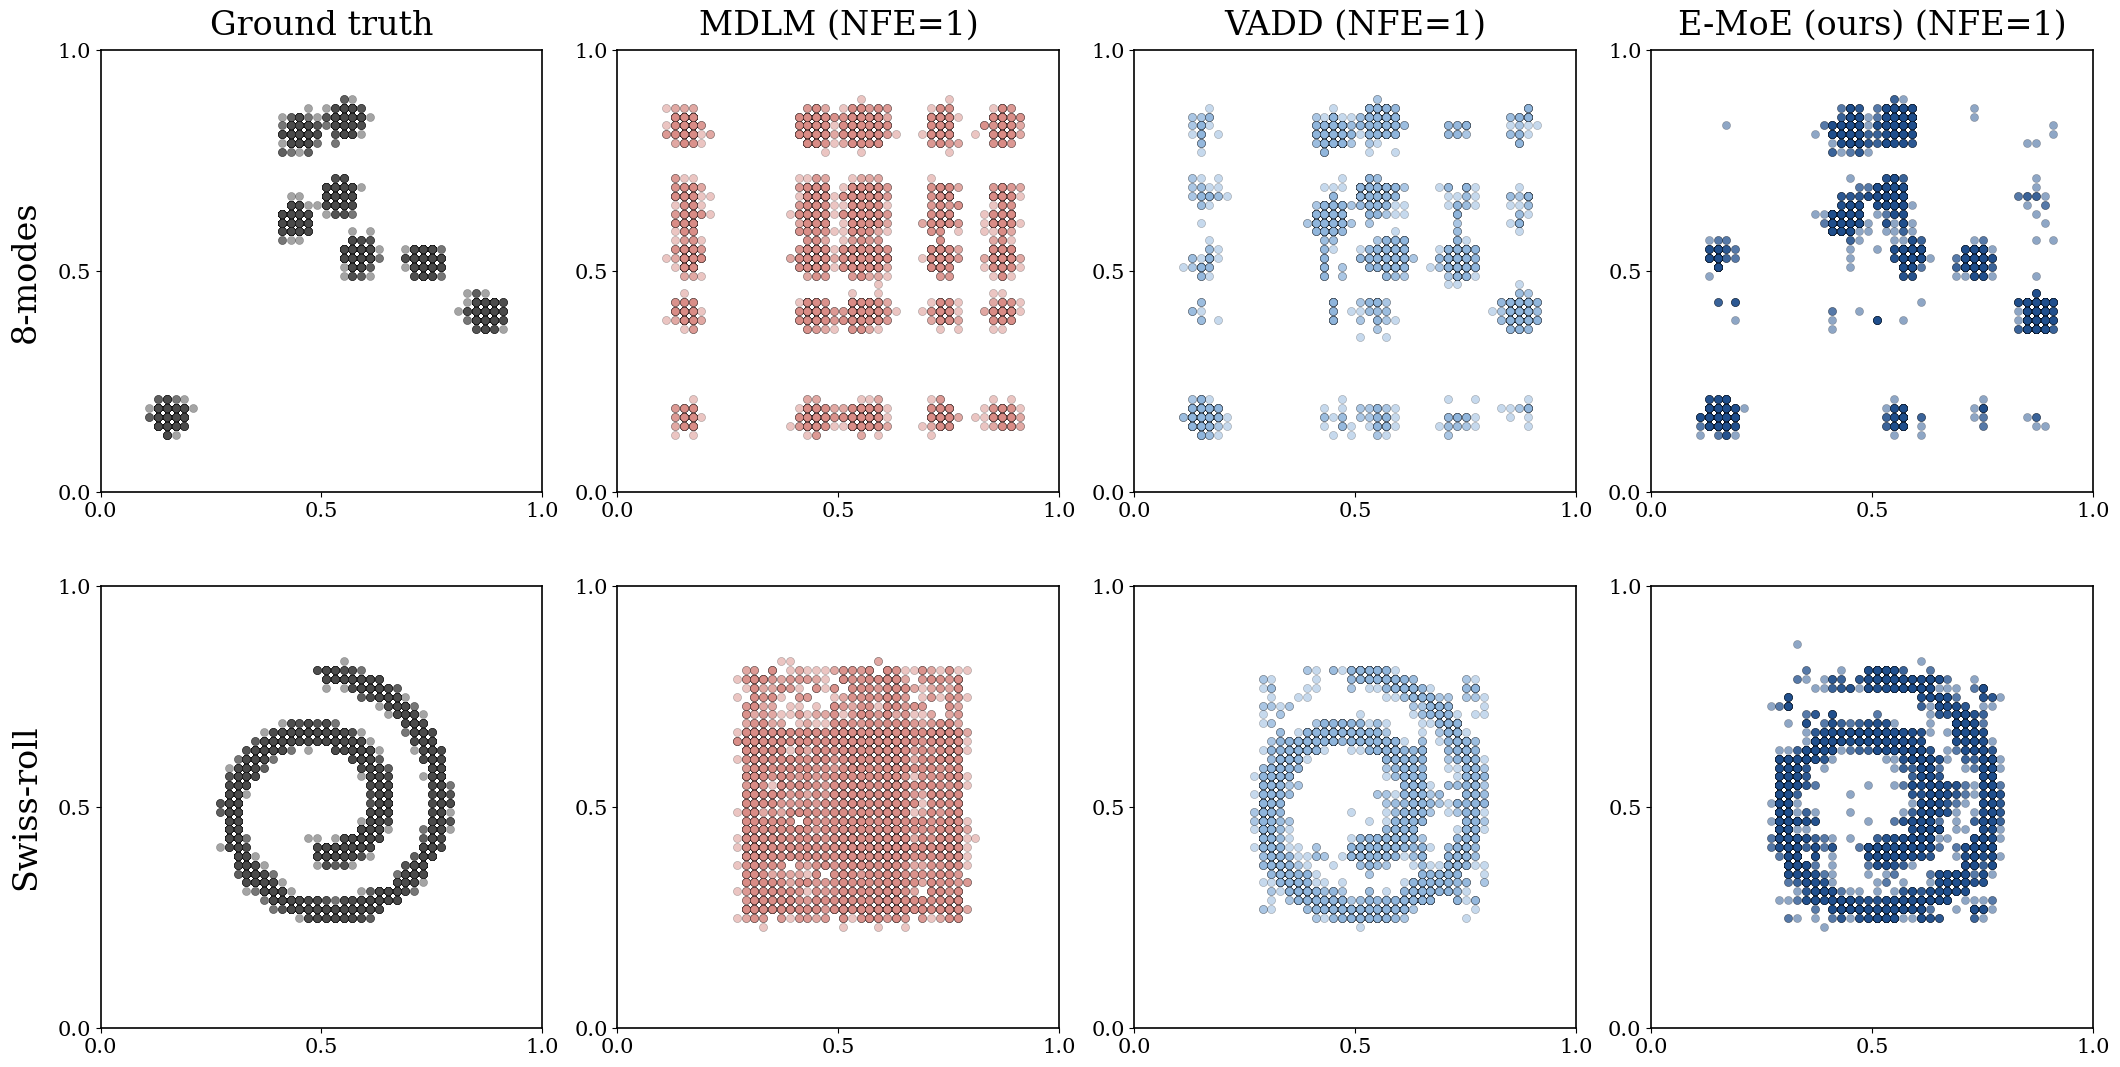

In [ ]:
GT_COLOR = '#4a4a4a'
C_MDLM = '#D98C86'
C_VADD = '#8FB5DC'
C_EMOE = '#1F4E8C'


def _scatter_panel(ax, tok, V, color, n_show, title='', ylabel='', dot_size=34, alpha=0.5):
    xy = _undiscretise(tok[:n_show], V)
    ax.scatter(xy[:, 0], xy[:, 1], s=dot_size, alpha=alpha, c=color,
              edgecolors='black', linewidths=0.25, rasterized=True)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.tick_params(labelsize=15)
    ax.set_aspect('equal')
    if title:
        ax.set_title(title, fontsize=24, pad=11)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=24, labelpad=11)
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_edgecolor('black')
        sp.set_linewidth(1.2)


def models_of(ds_name):
    s = models_seed0[ds_name]
    return s['c'], DATASETS[ds_name], s['MDLM'], s['EMOE'], s['VADD']


DATASET_LABELS = {'8modes': '8-modes', 'swiss_roll': 'Swiss-roll'}
MODEL_SPECS = [
    ('MDLM', C_MDLM, sample_mdlm, {}),
    ('VADD', C_VADD, sample_vadd, {}),
    ('E-MoE (ours)', C_EMOE, sample_emoe, {'tau': 0.01}),
]

N_SHOW, cell = 6000, 5.2
fig, axes = plt.subplots(2, 1 + len(MODEL_SPECS), figsize=(cell * 4 + 0.5, cell * 2 + 0.8))
for dsi, ds_name in enumerate(['8modes', 'swiss_roll']):
    c, ds, m, e, vadd_pair = models_of(ds_name)
    torch.manual_seed(0)
    np.random.seed(0)
    tokens, _ = ds['gen'](20000, 0, V=ds['V'], D=2, M=ds['M'])
    model_map = {'MDLM': m, 'VADD': vadd_pair, 'E-MoE (ours)': e}
    _scatter_panel(axes[dsi, 0], tokens.cpu().numpy(), ds['V'], GT_COLOR, N_SHOW,
                   title=('Ground truth' if dsi == 0 else ''), ylabel=DATASET_LABELS[ds_name])
    for j, (name, color, fn, kw) in enumerate(MODEL_SPECS, start=1):
        np.random.seed(42)
        torch.manual_seed(42)
        s = _batched_sample(model_map[name], fn, N_SHOW, 1, c, **kw)
        _scatter_panel(axes[dsi, j], s, ds['V'], color, N_SHOW,
                       title=(f'{name} (NFE=1)' if dsi == 0 else ''))
plt.tight_layout()
plt.show()

### Full NFE sweeps

8-modes


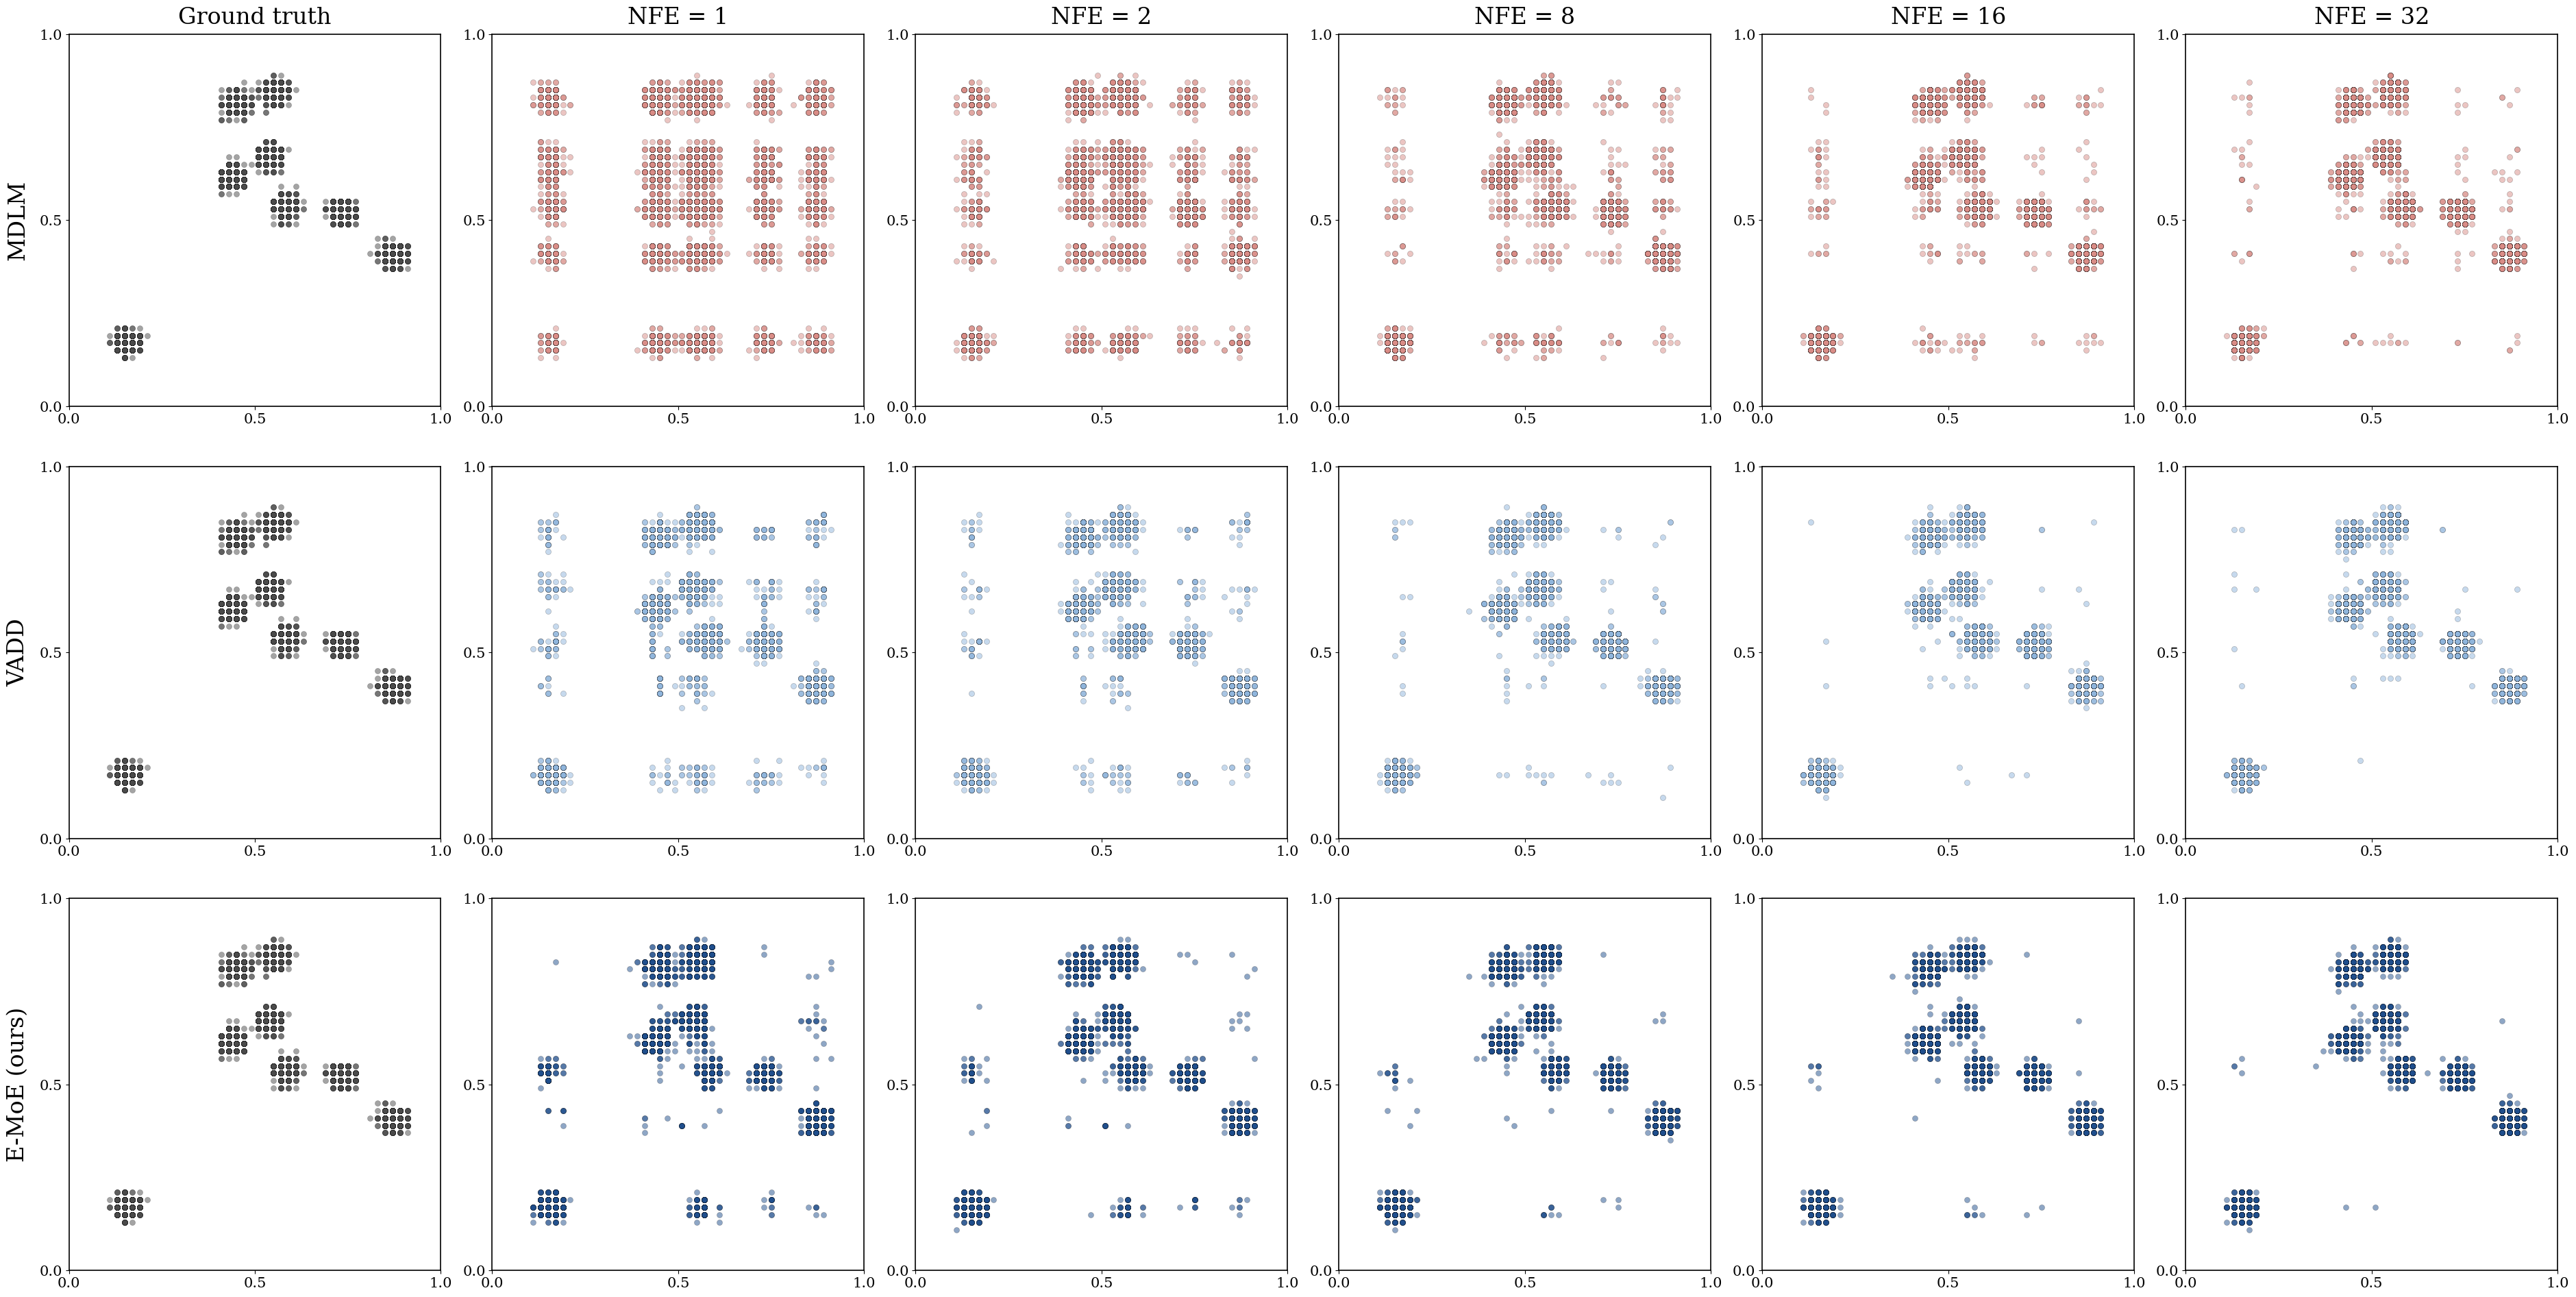

Swiss-roll


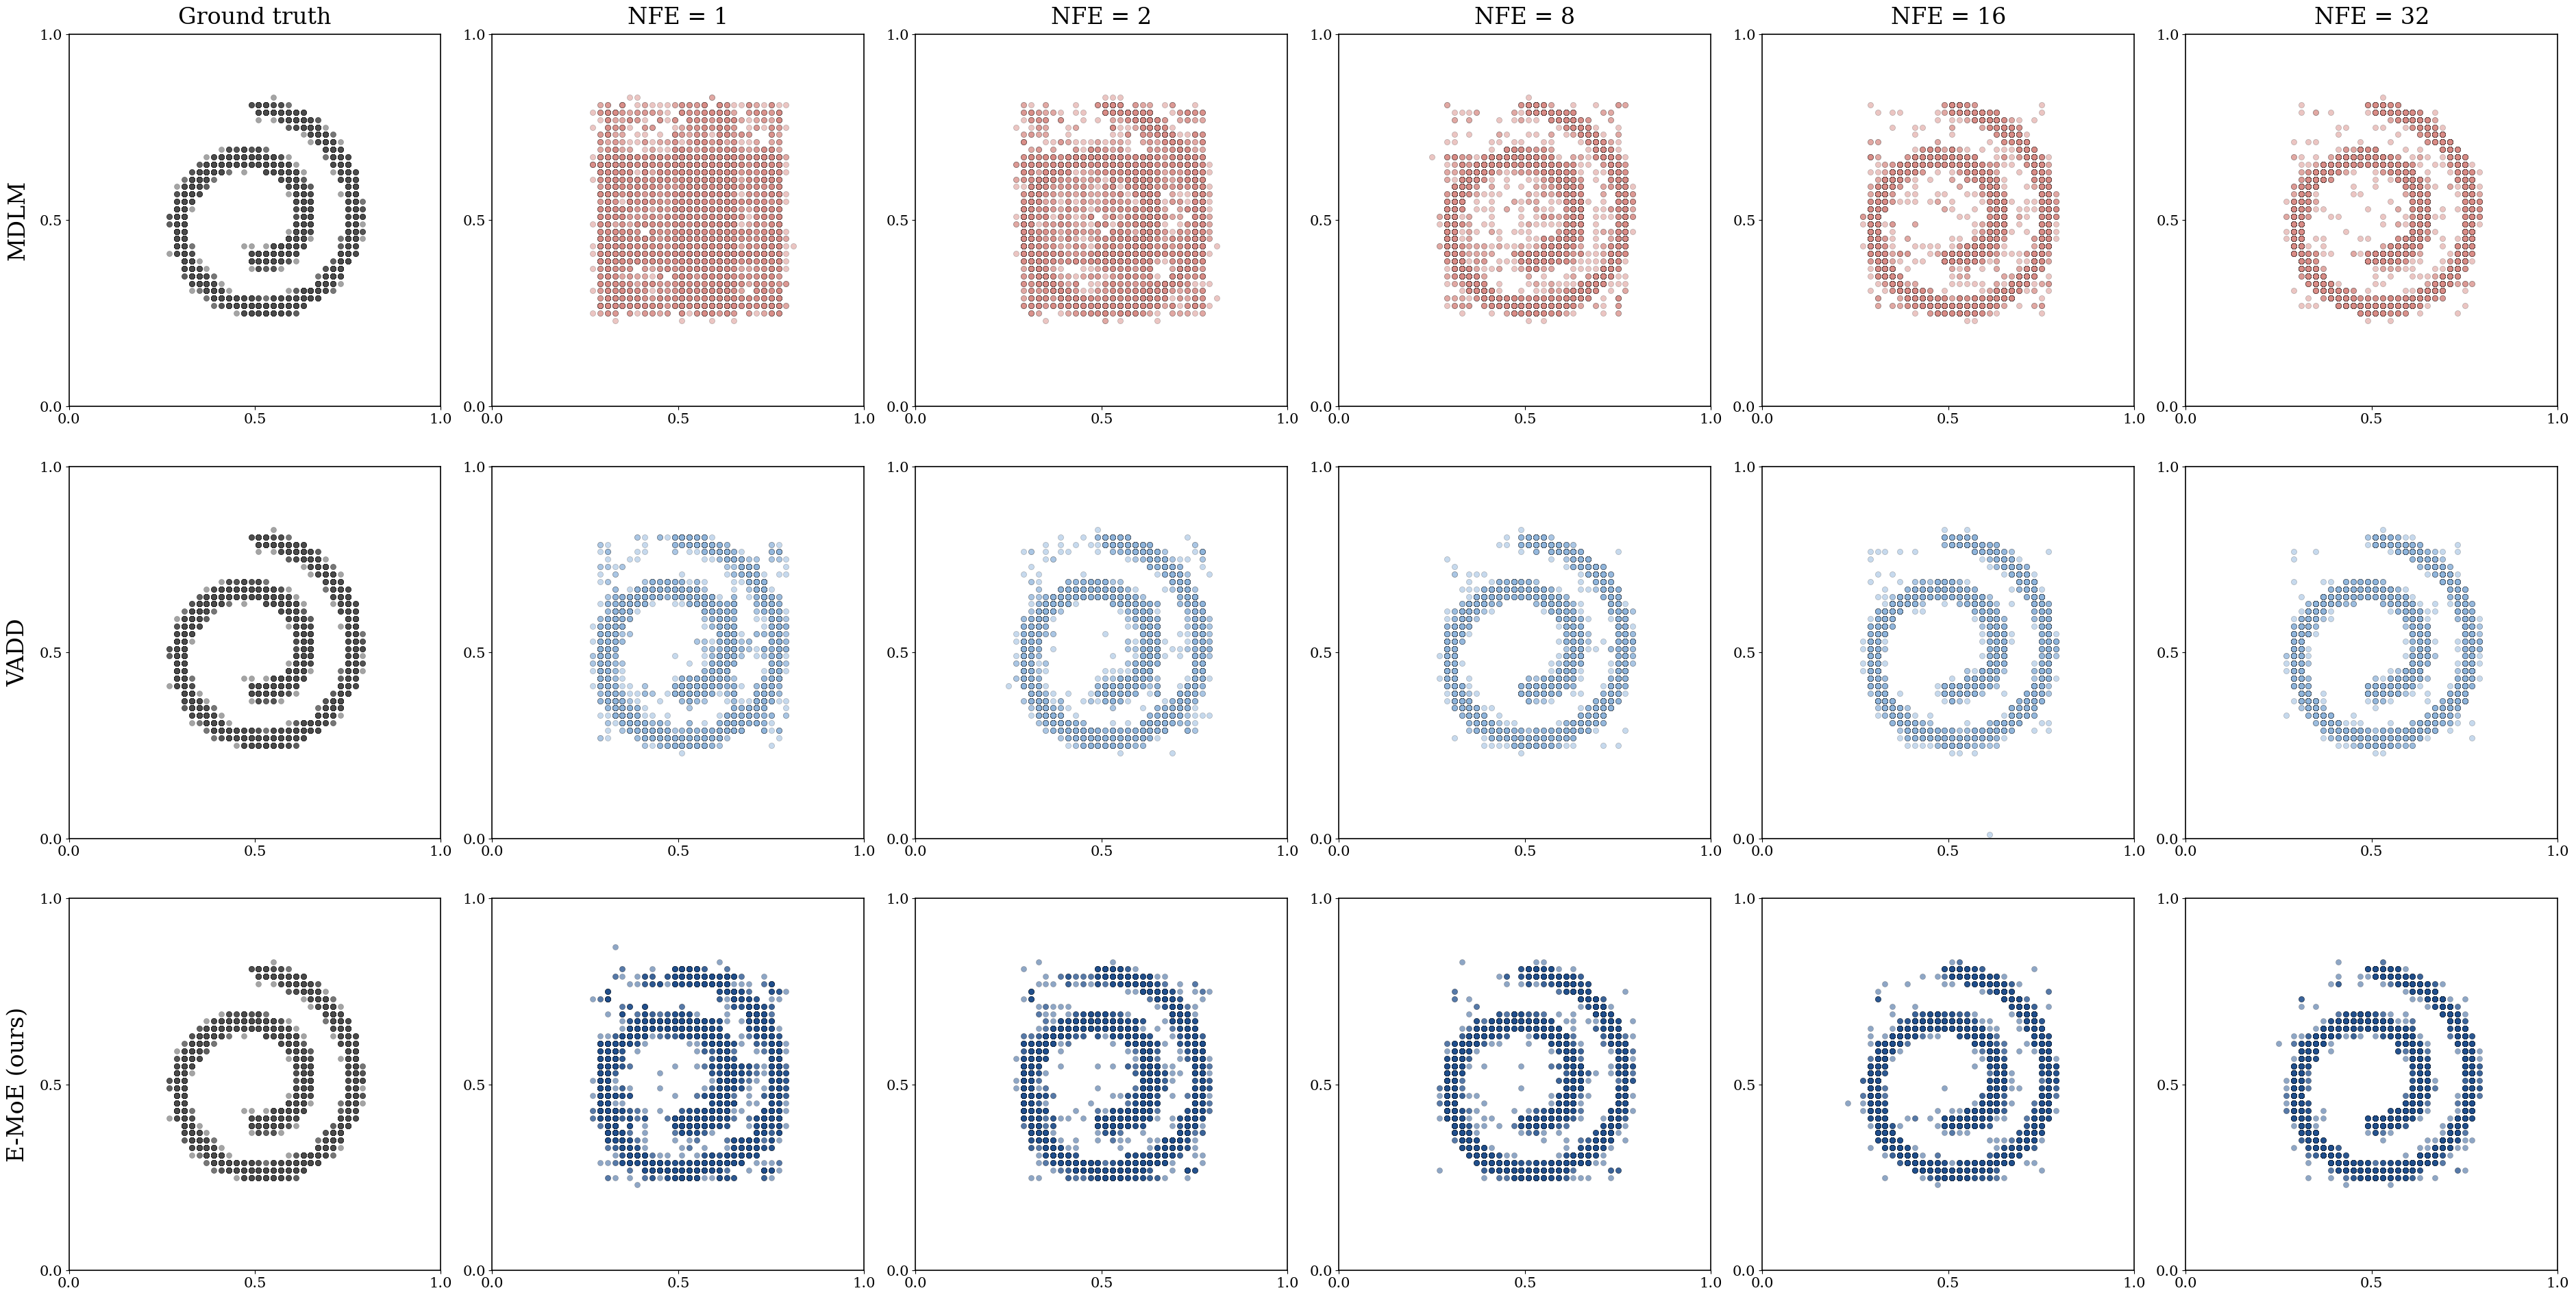

In [ ]:
def plot_nfe_grid(train_tokens, model_specs, c, nfe_list=(1, 2, 8, 16, 32), n_samples=6000):
    train_np = train_tokens.cpu().numpy()
    n_show = min(n_samples, train_np.shape[0])
    samples_by_model = {}
    for spec in model_specs:
        nm = spec['name']
        samples_by_model[nm] = {}
        kw = spec.get('sample_kwargs', {})
        for nfe in nfe_list:
            np.random.seed(42)
            torch.manual_seed(42)
            samples_by_model[nm][nfe] = _batched_sample(
                spec['model'], spec['sample_fn'], n_samples, nfe, c, **kw)
    n_rows = len(model_specs)
    cols = 1 + len(nfe_list)
    cell = 6.2
    fig, axes = plt.subplots(n_rows, cols,
                             figsize=(cell * cols + 0.5, cell * n_rows + 0.8),
                             squeeze=False)

    for r, spec in enumerate(model_specs):
        _scatter_panel(axes[r, 0], train_np, c.V, GT_COLOR, n_show,
                       title=('Ground truth' if r == 0 else ''), ylabel=spec['name'])
        for j, nfe in enumerate(nfe_list, start=1):
            _scatter_panel(axes[r, j], samples_by_model[spec['name']][nfe],
                          c.V, spec['color'], n_show,
                          title=(f'NFE = {nfe}' if r == 0 else ''))
    plt.tight_layout()
    plt.show()


for ds_name in ['8modes', 'swiss_roll']:
    c, ds, m, e, vadd_pair = models_of(ds_name)
    torch.manual_seed(0)
    np.random.seed(0)
    tokens, _ = ds['gen'](20000, 0, V=ds['V'], D=2, M=ds['M'])
    specs = [dict(name='MDLM', color=C_MDLM, model=m, sample_fn=sample_mdlm),
             dict(name='VADD', color=C_VADD, model=vadd_pair, sample_fn=sample_vadd),
             dict(name='E-MoE (ours)', color=C_EMOE, model=e, sample_fn=sample_emoe,
                  sample_kwargs={'tau': 0.01})]
    print(DATASET_LABELS[ds_name])
    plot_nfe_grid(tokens.to(DEVICE), specs, c, nfe_list=(1, 2, 8, 16, 32), n_samples=6000)